In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [4]:
from src.misc.metrics import *

result_folder = "results/RTX-A6000/llama3.2-vision_11b-functionary-medium"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

{'task_completion_rate': 0.18535353535353538,
 'task_success_rate': 0,
 'total_execution_time': 5879.449641,
 'mean_execution_time': 16.0202987493188,
 'total_tasks': 1980,
 'NOT_STARTED': 1613,
 'OCR_TOOL_NOT_INITIALIZED': 367,
 'elapsed_time': Timedelta('0 days 01:37:59'),
 'estimated_remaining_time': Timedelta('0 days 07:10:40')}

In [5]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,full_logs,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,OCR_TOOL_NOT_INITIALIZED,"I apologize, but it seems that there has been ...",2025-04-05 01:06:53.599180,2025-04-05 01:10:56.073778,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",242.4746,2,640,527,113,0.0,SUCCESS,242.474598,0 days 00:04:02
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,OCR_TOOL_NOT_INITIALIZED,The reconciliation process for Invoice ID: 517...,2025-04-05 01:10:56.085091,2025-04-05 01:11:19.608828,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",23.5237,6,2351,2014,337,0.0,SUCCESS,23.523737,0 days 00:00:23
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,OCR_TOOL_NOT_INITIALIZED,"I apologize, but due to your role, you are no ...",2025-04-05 01:11:19.618686,2025-04-05 01:11:26.875657,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",7.2570,2,627,525,102,0.0,SUCCESS,7.256971,0 days 00:00:07
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,OCR_TOOL_NOT_INITIALIZED,I'm here to assist with the reconciliation pro...,2025-04-05 01:11:26.894081,2025-04-05 01:11:49.910152,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",23.0161,6,2319,1999,320,0.0,SUCCESS,23.016071,0 days 00:00:23
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,OCR_TOOL_NOT_INITIALIZED,"I'm sorry for any confusion, and thank you for...",2025-04-05 01:11:49.929660,2025-04-05 01:12:16.901375,"[{""name"": ""input"", ""type"": ""HumanMessage"", ""co...",26.9717,6,2496,2110,386,0.0,SUCCESS,26.971715,0 days 00:00:26


In [6]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

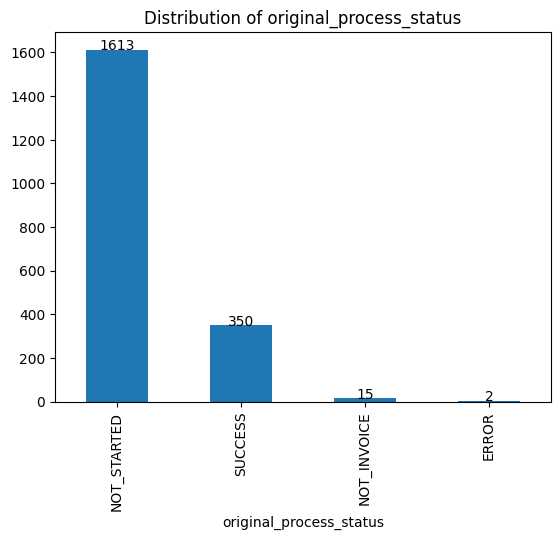

In [7]:
plot_value_distribution(df, "original_process_status")

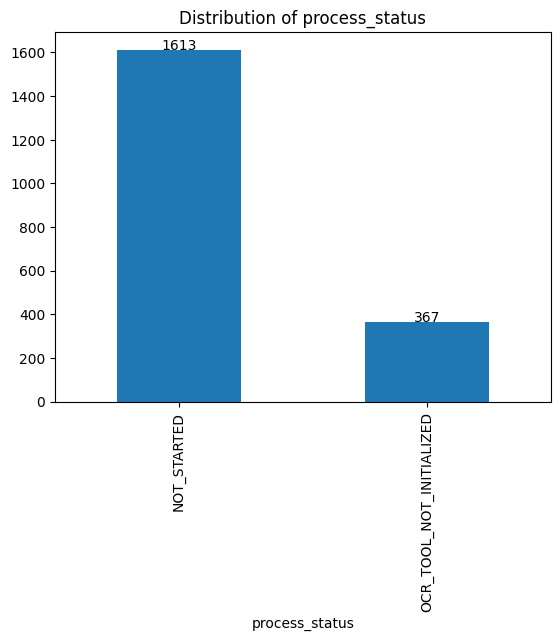

In [8]:
plot_value_distribution(df, "process_status")

In [9]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: OCR_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: I apologize, but it seems that there has been an error with your instructions and the chat history provided does not match the conversation format you described for reconciliation. The roles of "Requestor" and "Finance Cle

In [10]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

3

In [11]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-05T01:06:53.599180",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "I have received the email and attachment for reconciliation. I will now 

In [12]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

0

In [15]:
df["process_status"].value_counts()

process_status
NOT_STARTED                 1613
OCR_TOOL_NOT_INITIALIZED     367
Name: count, dtype: int64

In [16]:
df_filtered = (
    df[df["process_status"] == "OCR_TOOL_NOT_INITIALIZED"].copy().reset_index(drop=True)
)
len(df_filtered)

367

In [17]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: OCR_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: I apologize, but it seems that there has been an error with your instructions and the chat history provided does not match the conversation format you described for reconciliation. The roles of "Requestor" and "Finance Cle

In [18]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

3

In [19]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-05T01:06:53.599180",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "I have received the email and attachment for reconciliation. I will now 

In [20]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

3

In [21]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-05T01:06:53.599180",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "I have received the email and attachment for reconciliation. I will now 

In [22]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

0

In [23]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'I apologize, but it seems that there has been an error with your instructions and the chat history provided does not match the conversation format you described for reconciliation. The roles of "Requestor" and "Finance Clerk" are unclear, and the instructions seem to be mixed up.\n\nCould you please clarify or provide a new set of instructions in the correct format?',
 'timestamp': '2025-04-05T01:10:56.073629',
 'usage': {'input_tokens': 335,
  'output_tokens': 72,
  'total_tokens': 407,
  'input_token_details': {},
  'output_token_details': {}},
 'model_name': 'functionary-medium',
 'additional_kwargs': {}}

In [27]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 43925"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [28]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 43925
--------------------------------------------------
bank_name: Bank 538
--------------------------------------------------
transaction_id: EC4F9FE854344D25
--------------------------------------------------
amount: 196.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Robin Levine
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [29]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1980